In [1]:
query = '''
    WITH new_users AS (
        SELECT user_id, create_date as user_join_date
        FROM vod."user" u
        WHERE NOT EXISTS (
            SELECT 1 FROM vod.payments p
            WHERE p.user_id = u.user_id AND p.payment_status = 'SUCCESS'
        )
    ),
    first_purchase_stats AS (
        WITH first_successful_payment AS (
            SELECT 
                user_id,
                film_id,
                (price - (price * discount_percentage) - COALESCE(voucher_value, 0)) AS final_amount,
                ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY create_date ASC) AS rn
            FROM vod.payments
            WHERE payment_status = 'SUCCESS'
        )
        SELECT 
            film_id,
            COUNT(user_id) AS first_time_buyers,
            SUM(final_amount) AS first_purchase_revenue,
            AVG(final_amount) AS first_purchase_avg,
            MIN(final_amount) AS first_purchase_min,
            MAX(final_amount) AS first_purchase_max
        FROM first_successful_payment
        WHERE rn = 1
        GROUP BY film_id
    )
    SELECT 
        e.film_id,
        f.title as film_title,
        COUNT(DISTINCT e.user_id) as new_user_unique_users,
        COUNT(*) as new_user_total_events,
        COUNT(CASE WHEN e.event_type = 'click' THEN 1 END) as new_user_clicks,
        COUNT(CASE WHEN e.event_type = 'add_to_basket' THEN 1 END) as new_user_basket_adds,
        COUNT(CASE WHEN e.event_type = 'payment' THEN 1 END) as new_user_payments,
        MIN(e.create_date) as first_event_date,
        MAX(e.create_date) as last_event_date,
        -- نرخ‌ها
        ROUND(
            COUNT(CASE WHEN e.event_type = 'add_to_basket' THEN 1 END) * 100.0 / 
            NULLIF(COUNT(CASE WHEN e.event_type = 'click' THEN 1 END), 0), 2
        ) as new_user_click_to_basket_rate_percent,
        ROUND(
            COUNT(CASE WHEN e.event_type = 'payment' THEN 1 END) * 100.0 / 
            NULLIF(COUNT(CASE WHEN e.event_type = 'click' THEN 1 END), 0), 2
        ) as new_user_click_to_payment_rate_percent,
        ROUND(
            COUNT(CASE WHEN e.event_type = 'payment' THEN 1 END) * 100.0 / 
            NULLIF(COUNT(CASE WHEN e.event_type = 'add_to_basket' THEN 1 END), 0), 2
        ) as new_user_basket_to_payment_rate_percent,
        -- اولین خرید
        COALESCE(fps.first_time_buyers, 0) as first_time_buyers,
        COALESCE(fps.first_purchase_revenue,0) as first_purchase_revenue,
        COALESCE(fps.first_purchase_avg,0) as first_purchase_avg,
        COALESCE(fps.first_purchase_min,0) as first_purchase_min,
        COALESCE(fps.first_purchase_max,0) as first_purchase_max
    FROM vod.events e
    JOIN new_users nu ON e.user_id = nu.user_id
    LEFT JOIN vod.film f ON e.film_id = f.film_id
    LEFT JOIN first_purchase_stats fps ON e.film_id = fps.film_id
    WHERE e.film_id != -1
    GROUP BY e.film_id, f.title, fps.first_time_buyers, fps.first_purchase_revenue, 
             fps.first_purchase_avg, fps.first_purchase_min, fps.first_purchase_max
    ORDER BY new_user_total_events DESC;
'''


In [2]:
query1 = '''
    WITH new_users AS (
        SELECT user_id, create_date as user_join_date
        FROM vod."user" u
        WHERE NOT EXISTS (
            SELECT 1 FROM vod.payments p
            WHERE p.user_id = u.user_id AND p.payment_status = 'SUCCESS'
        )
    ),
    first_purchase_stats AS (
        WITH first_successful_payment AS (
            SELECT 
                user_id,
                film_id,
                (price - (price * discount_percentage / 100.0) - COALESCE(voucher_value, 0)) AS final_amount,
                ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY create_date ASC) AS rn
            FROM vod.payments
            WHERE payment_status = 'SUCCESS'
        )
        SELECT 
            film_id,
            COUNT(user_id) AS first_time_buyers,
            SUM(final_amount) AS first_purchase_revenue,
            AVG(final_amount) AS first_purchase_avg,
            MIN(final_amount) AS first_purchase_min,
            MAX(final_amount) AS first_purchase_max
        FROM first_successful_payment
        WHERE rn = 1
        GROUP BY film_id
    )
    SELECT 
        e.film_id,
    	c.name as category,
        f.title as film_title,
        COUNT(DISTINCT e.user_id) as new_user_unique_users,
        COUNT(*) as new_user_total_events,
        COUNT(CASE WHEN e.event_type = 'click' THEN 1 END) as new_user_clicks,
        COUNT(CASE WHEN e.event_type = 'add_to_basket' THEN 1 END) as new_user_basket_adds,
        COUNT(CASE WHEN e.event_type = 'payment' THEN 1 END) as new_user_payments,
        MIN(e.create_date) as first_event_date,
        MAX(e.create_date) as last_event_date,
        -- نرخ‌ها
        ROUND(
            COUNT(CASE WHEN e.event_type = 'add_to_basket' THEN 1 END) * 100.0 / 
            NULLIF(COUNT(CASE WHEN e.event_type = 'click' THEN 1 END), 0), 2
        ) as new_user_click_to_basket_rate_percent,
        ROUND(
            COUNT(CASE WHEN e.event_type = 'payment' THEN 1 END) * 100.0 / 
            NULLIF(COUNT(CASE WHEN e.event_type = 'click' THEN 1 END), 0), 2
        ) as new_user_click_to_payment_rate_percent,
        ROUND(
            COUNT(CASE WHEN e.event_type = 'payment' THEN 1 END) * 100.0 / 
            NULLIF(COUNT(CASE WHEN e.event_type = 'add_to_basket' THEN 1 END), 0), 2
        ) as new_user_basket_to_payment_rate_percent,
        -- اولین خرید
        COALESCE(fps.first_time_buyers, 0) as first_time_buyers,
        COALESCE(fps.first_purchase_revenue,0) as first_purchase_revenue,
        COALESCE(fps.first_purchase_avg,0) as first_purchase_avg,
        COALESCE(fps.first_purchase_min,0) as first_purchase_min,
        COALESCE(fps.first_purchase_max,0) as first_purchase_max
    FROM vod.events e
    JOIN new_users nu ON e.user_id = nu.user_id
    LEFT JOIN vod.film f ON e.film_id = f.film_id
    LEFT JOIN first_purchase_stats fps ON e.film_id = fps.film_id
    LEFT JOIN vod.film_category as fc ON e.film_id = fc.film_id
    LEFT JOIN vod.category as c ON fc.category_id = c.category_id
    
    WHERE e.film_id != -1
    GROUP BY e.film_id, f.title, fps.first_time_buyers, fps.first_purchase_revenue, 
             fps.first_purchase_avg, fps.first_purchase_min, fps.first_purchase_max,fc.category_id , c.name
    ORDER BY new_user_total_events DESC;
'''

In [3]:
import pandas as pd
import sys
sys.path.extend(['/home/jovyan/modules'])

from db_connector import *

films = pd.read_sql_query(query1,bootcamp_db)
films

,film_id,category,film_title,new_user_unique_users,new_user_total_events,new_user_clicks,new_user_basket_adds,new_user_payments,first_event_date,last_event_date,new_user_click_to_basket_rate_percent,new_user_click_to_payment_rate_percent,new_user_basket_to_payment_rate_percent,first_time_buyers,first_purchase_revenue,first_purchase_avg,first_purchase_min,first_purchase_max
0,739,Drama,ROCKY WAR,1828,2992,1844,1125,23,2026-05-20 07:54:00,2026-06-19 23:18:00,61.01,1.25,2.04,910,40950.0,45.000000,45.0,45.0
1,146,Drama,CHITTY LOCK,1817,2958,1824,1123,11,2026-05-20 05:40:00,2026-06-19 23:21:00,61.57,0.60,0.98,670,30140.0,44.985075,35.0,45.0
2,958,Drama,WARDROBE PHANTOM,1813,2956,1831,1106,19,2026-05-20 05:40:00,2026-06-19 23:07:00,60.40,1.04,1.72,685,30815.0,44.985401,35.0,45.0
3,225,Drama,DESTINATION JERK,1797,2955,1807,1110,38,2026-05-20 04:39:00,2026-06-19 23:14:00,61.43,2.10,3.42,1287,57905.0,44.992230,35.0,45.0
4,979,Drama,WITCHES PANIC,1780,2953,1786,1126,41,2026-05-20 03:33:00,2026-06-19 23:11:00,63.05,2.30,3.64,1796,80805.0,44.991648,30.0,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,429,Sports,HONEY TIES,194,304,194,110,0,2026-05-20 05:41:00,2026-06-19 23:06:00,56.70,0.00,0.00,3,135.0,45.000000,45.0,45.0
996,420,Sports,HOLES BRANNIGAN,190,301,190,110,1,2026-05-20 16:54:00,2026-06-19 23:05:00,57.89,0.53,0.91,9,405.0,45.000000,45.0,45.0
997,187,Sports,CRANES RESERVOIR,176,297,176,120,1,2026-05-20 12:42:00,2026-06-19 22:59:00,68.18,0.57,0.83,4,180.0,45.000000,45.0,45.0
998,383,Sports,GROOVE FICTION,193,292,193,98,1,2026-05-20 18:49:00,2026-06-19 23:05:00,50.78,0.52,1.02,13,585.0,45.000000,45.0,45.0


In [4]:
films.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   film_id                                  1000 non-null   int64         
 1   category                                 1000 non-null   object        
 2   film_title                               1000 non-null   object        
 3   new_user_unique_users                    1000 non-null   int64         
 4   new_user_total_events                    1000 non-null   int64         
 5   new_user_clicks                          1000 non-null   int64         
 6   new_user_basket_adds                     1000 non-null   int64         
 7   new_user_payments                        1000 non-null   int64         
 8   first_event_date                         1000 non-null   datetime64[ns]
 9   last_event_date                          1

In [5]:
films.describe()

,film_id,new_user_unique_users,new_user_total_events,new_user_clicks,new_user_basket_adds,new_user_payments,first_event_date,last_event_date,new_user_click_to_basket_rate_percent,new_user_click_to_payment_rate_percent,new_user_basket_to_payment_rate_percent,first_time_buyers,first_purchase_revenue,first_purchase_avg,first_purchase_min,first_purchase_max
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,957.606000,1592.757000,962.384000,596.909000,33.464000,2026-05-20 08:05:54.180000,2026-06-19 23:10:57.420000,62.655360,5.119130,7.606540,788.388000,35448.584040,44.708234,35.947022,44.760000
min,1.000000,172.000000,287.000000,172.000000,98.000000,0.000000,2026-05-20 00:08:00,2026-06-19 19:06:00,50.780000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,250.750000,675.500000,1126.500000,678.000000,424.000000,14.000000,2026-05-20 05:40:00,2026-06-19 23:05:00,60.777500,1.250000,2.070000,283.250000,12702.553125,44.943967,30.000000,45.000000
50%,500.500000,921.000000,1528.000000,924.500000,576.000000,26.000000,2026-05-20 07:56:00,2026-06-19 23:13:00,61.955000,2.560000,4.155000,675.500000,30354.080000,44.974498,34.955000,45.000000
75%,750.250000,1295.500000,2125.250000,1300.000000,804.250000,43.000000,2026-05-20 09:52:00,2026-06-19 23:18:00,63.350000,4.630000,7.352500,1130.250000,50843.486250,45.000000,45.000000,45.000000
max,1000.000000,1828.000000,2992.000000,1844.000000,1127.000000,273.000000,2026-05-22 03:48:00,2026-06-19 23:22:00,81.090000,50.140000,62.670000,5090.000000,228775.000000,45.000000,45.000000,45.000000
std,288.819436,452.034408,730.972508,455.330291,276.512709,32.019618,NaN,NaN,3.687952,8.302026,11.222592,676.509234,30428.890618,3.207266,7.206220,3.209782


--- [1] بررسی سلامت داده‌ها ---
تعداد کل رکوردها: 1000
✅ تمام ستون‌های مورد نیاز برای تحلیل یافت شدند.

--- [2] ۱۰ فیلم برتر از نظر نرخ تبدیل (Basket to Payment) ---


,film_title,new_user_basket_to_payment_rate_percent,new_user_payments,first_purchase_revenue
810,FAMILY SWEET,62.67,183,171520.0
947,WIZARD COLDBLOODED,61.98,75,89045.0
925,OUTFIELD MASSACRE,59.18,87,81430.0
906,DEER VIRGINIAN,58.60,92,86640.0
812,EGYPT TENENBAUMS,58.51,165,161875.0
921,TELEGRAPH VOYAGE,57.72,86,87985.0
929,BIRDCAGE CASPER,54.29,76,75140.0
911,GREATEST NORTH,51.83,85,82385.0
523,PINOCCHIO SIMON,51.70,273,228775.0
913,SILENCE KANE,51.53,84,81190.0



--- [3] آمار توزیع نرخ تبدیل سبد به پرداخت ---
count    1000.000000
mean        7.606540
std        11.222592
min         0.000000
5%          0.000000
25%         2.070000
50%         4.155000
75%         7.352500
95%        40.008500
max        62.670000
Name: new_user_basket_to_payment_rate_percent, dtype: float64

--- [4] تحلیل همبستگی بین متغیرهای کلیدی ---


,new_user_basket_to_payment_rate_percent,new_user_click_to_basket_rate_percent,new_user_click_to_payment_rate_percent,new_user_unique_users,first_time_buyers,first_purchase_avg,first_purchase_revenue
new_user_basket_to_payment_rate_percent,1.000000,0.854497,0.997502,-0.418962,0.639764,0.050475,0.639546
new_user_click_to_basket_rate_percent,0.854497,1.000000,0.868524,-0.362085,0.519210,0.096557,0.519019
new_user_click_to_payment_rate_percent,0.997502,0.868524,1.000000,-0.418505,0.622987,0.046295,0.622776
new_user_unique_users,-0.418962,-0.362085,-0.418505,1.000000,0.059244,0.117627,0.059179
first_time_buyers,0.639764,0.519210,0.622987,0.059244,1.000000,0.092799,1.000000
first_purchase_avg,0.050475,0.096557,0.046295,0.117627,0.092799,1.000000,0.092788
first_purchase_revenue,0.639546,0.519019,0.622776,0.059179,1.000000,0.092788,1.000000



--- [5] در حال تولید نمودارها... ---


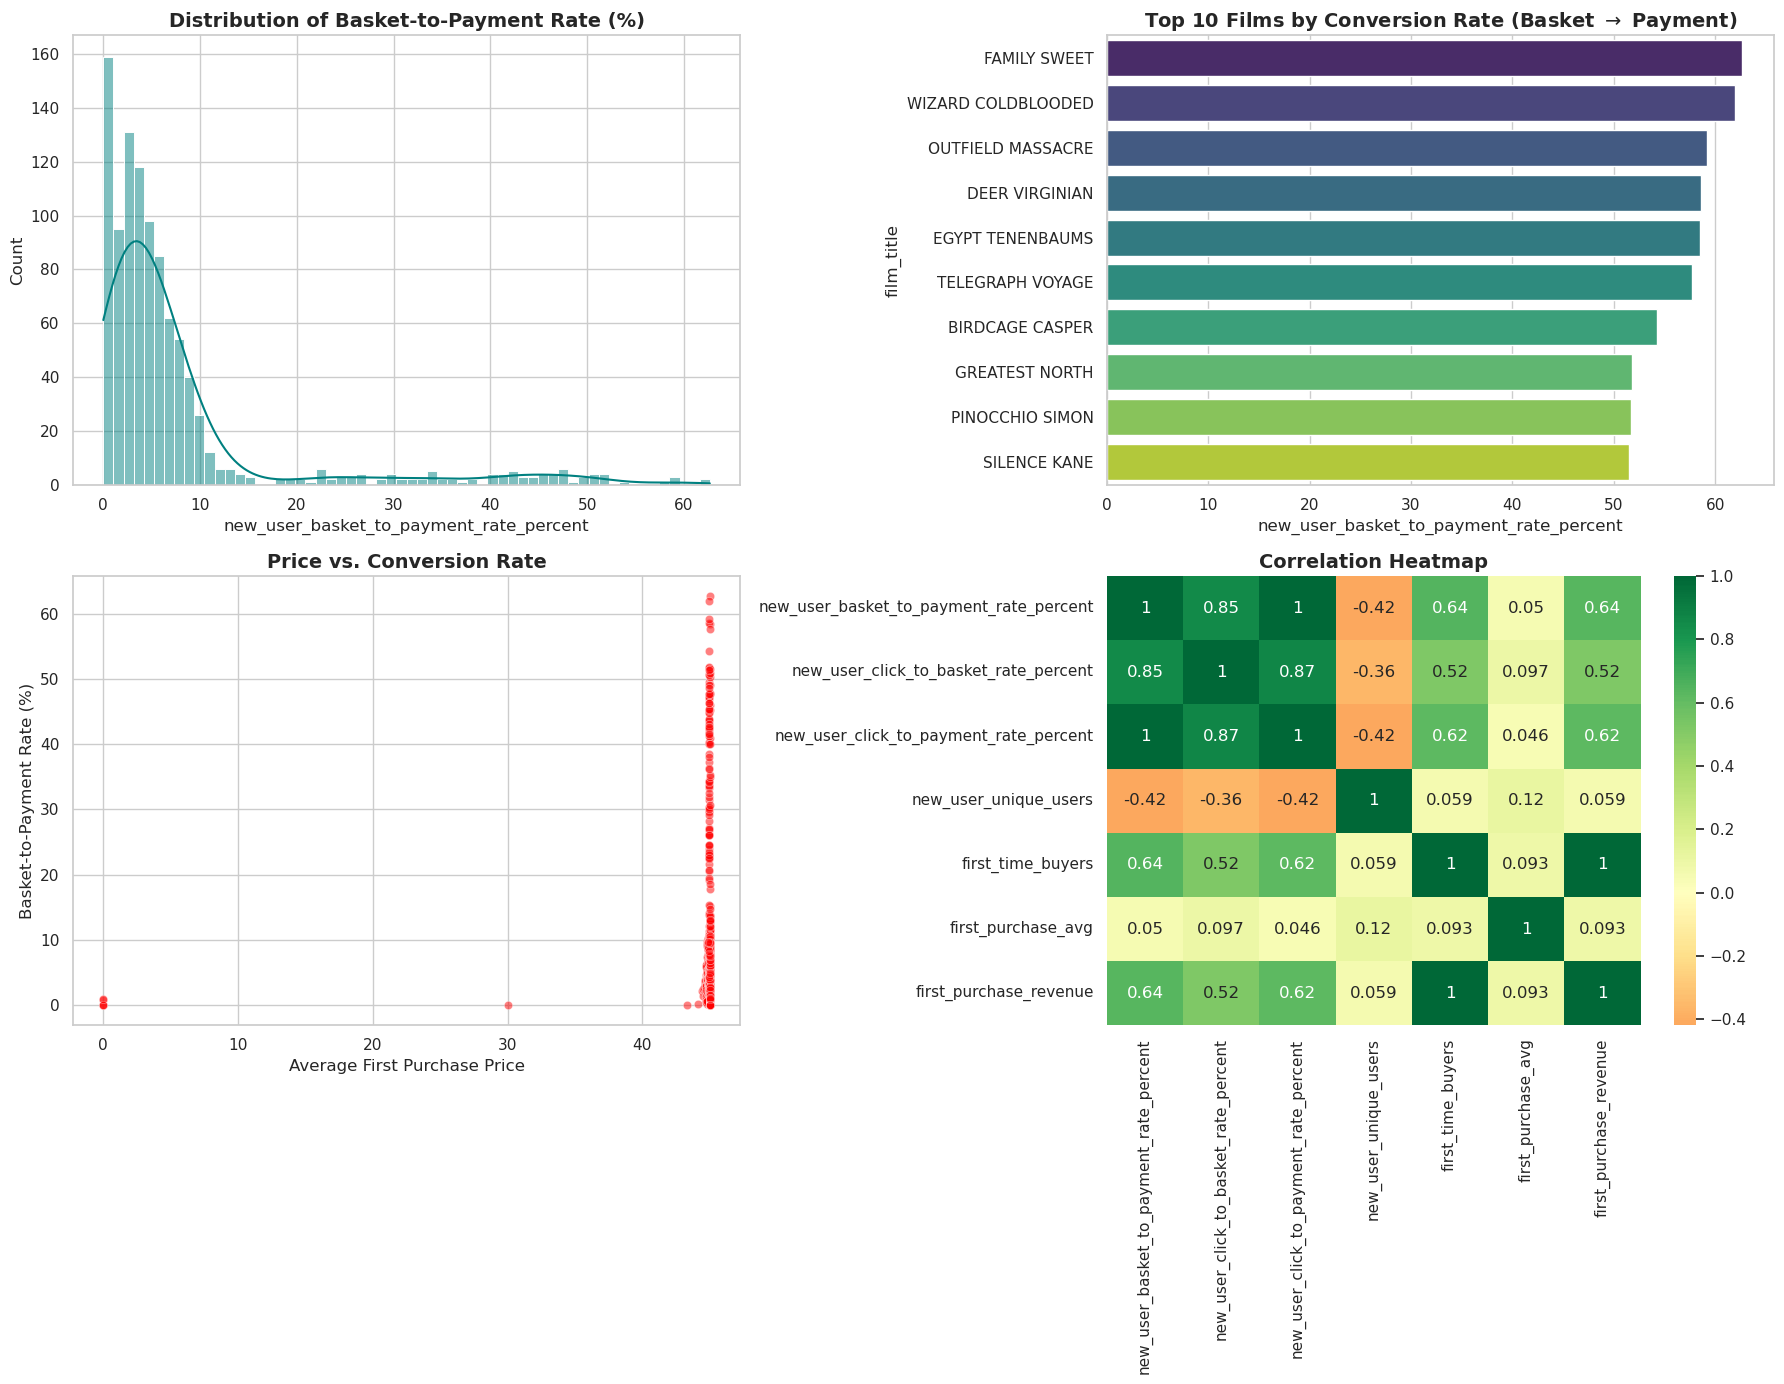

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# تنظیم استایل برای نمایش بهتر در Notebook
%matplotlib inline
sns.set_theme(style="whitegrid")

# فرض می‌کنیم دیتافریم شما با نام 'films' در حافظه موجود است
df = films.copy()

print("--- [1] بررسی سلامت داده‌ها ---")
print(f"تعداد کل رکوردها: {len(df)}")
# بررسی وجود ستون‌های مورد نیاز
required_cols = [
    'film_title',
    'new_user_basket_to_payment_rate_percent',
    'new_user_click_to_basket_rate_percent',
    'new_user_click_to_payment_rate_percent',
    'first_purchase_avg',
    'first_time_buyers',
    'first_purchase_revenue'
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    print(f"⚠️ هشدار: ستون‌های زیر یافت نشدند: {missing}")
else:
    print("✅ تمام ستون‌های مورد نیاز برای تحلیل یافت شدند.")

# --- [2] شناسایی ۱۰ فیلم برتر از نظر نرخ تبدیل سبد به پرداخت ---
print("\n--- [2] ۱۰ فیلم برتر از نظر نرخ تبدیل (Basket to Payment) ---")
top_10_conv = df.nlargest(10, 'new_user_basket_to_payment_rate_percent')[
    ['film_title', 'new_user_basket_to_payment_rate_percent', 'new_user_payments', 'first_purchase_revenue']
]
display(top_10_conv) # استفاده از display برای نمایش زیباتر در Jupyter

# --- [3] تحلیل توزیع نرخ تبدیل ---
print("\n--- [3] آمار توزیع نرخ تبدیل سبد به پرداخت ---")
print(df['new_user_basket_to_payment_rate_percent'].describe(percentiles=[.05, .25, .5, .75, .95]))

# --- [4] تحلیل همبستگی (Correlation) ---
print("\n--- [4] تحلیل همبستگی بین متغیرهای کلیدی ---")
# انتخاب ستون‌های عددی مرتبط برای تحلیل همبستگی
corr_cols = [
    'new_user_basket_to_payment_rate_percent', 
    'new_user_click_to_basket_rate_percent',
    'new_user_click_to_payment_rate_percent',
    'new_user_unique_users',
    'first_time_buyers',
    'first_purchase_avg',
    'first_purchase_revenue'
]
# فقط ستون‌هایی که واقعاً در df هستند را انتخاب می‌کنیم
existing_corr_cols = [c for c in corr_cols if c in df.columns]
correlation_matrix = df[existing_corr_cols].corr()
display(correlation_matrix)

# --- [5] تجسم‌سازی (Visualization) ---
print("\n--- [5] در حال تولید نمودارها... ---")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# نمودار ۱: توزیع نرخ تبدیل
sns.histplot(df['new_user_basket_to_payment_rate_percent'], kde=True, color='teal', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Basket-to-Payment Rate (%)', fontsize=14, fontweight='bold')

# نمودار ۲: ۱۰ فیلم برتر
sns.barplot(data=top_10_conv, x='new_user_basket_to_payment_rate_percent', y='film_title',hue='film_title',legend=False, palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('Top 10 Films by Conversion Rate (Basket $\\rightarrow$ Payment)', fontsize=14, fontweight='bold')

# نمودار ۳: رابطه قیمت و نرخ تبدیل (Scatter Plot)
sns.scatterplot(data=df, x='first_purchase_avg', y='new_user_basket_to_payment_rate_percent', alpha=0.5, color='red', ax=axes[1, 0])
axes[1, 0].set_title('Price vs. Conversion Rate', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Average First Purchase Price')
axes[1, 0].set_ylabel('Basket-to-Payment Rate (%)')

# نمودار ۴: Heatmap همبستگی
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0, ax=axes[1, 1])
axes[1, 1].set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# فرض می‌کنیم دیتافریم شما با نام 'films' در حافظه موجود است
df = films.copy()

def calculate_category_popularity_with_sklearn(df):
    """
    محاسبه شاخص محبوبیت دسته‌بندی‌ها با استفاده از MinMaxScaler از sklearn
    """
    
    # ۱. گروه‌بندی و محاسبه میانگین‌ها برای هر دسته‌بندی
    cat_stats = df.groupby('category').agg({
        'new_user_unique_users': 'mean',          # میانگین ترافیک
        'first_purchase_revenue': 'mean',         # میانگین درآمد
        'new_user_basket_to_payment_rate_percent': 'mean' # میانگین نرخ تبدیل
    }).reset_index()

    cat_stats.columns = ['category', 'avg_users', 'avg_revenue', 'avg_conversion']

    # ۲. آماده‌سازی ستون‌ها برای Scaler
    # sklearn نیاز دارد که داده‌ها به صورت دو بعدی (Matrix) باشند
    features_to_scale = ['avg_users', 'avg_revenue', 'avg_conversion']
    scaler = MinMaxScaler()

    # ۳. اعمال MinMaxScaler (نرمال‌سازی بین ۰ و ۱)
    # این متد دقیقا همان کاری را می‌کند که در کد قبلی دستی انجام دادیم اما با دقت ریاضی بالاتر
    cat_stats[[f'score_{col}' for col in features_to_scale]] = scaler.fit_transform(cat_stats[features_to_scale])

    # تغییر نام ستون‌های اسکیل شده برای هماهنگی با منطق قبلی
    cat_stats.rename(columns={
        'score_avg_users': 'score_users',
        'score_avg_revenue': 'score_revenue',
        'score_avg_conversion': 'score_conversion'
    }, inplace=True)

    # ۴. محاسبه امتیاز نهایی (Popularity Index) با وزن‌دهی
    # وزن‌ها: ۴۰٪ ترافیک، ۳۰٪ درآمد، ۳۰٪ نرخ تبدیل
    cat_stats['popularity_index'] = (
        (cat_stats['score_users'] * 0.40) + 
        (cat_stats['score_revenue'] * 0.30) + 
        (cat_stats['score_conversion'] * 0.30)
    )

    # ۵. مرتب‌سازی و انتخاب ستون‌های نهایی
    popularity_ranking = cat_stats.sort_values(by='popularity_index', ascending=False)
    
    result = popularity_ranking[[
        'category', 
        'popularity_index', 
        'avg_users', 
        'avg_revenue', 
        'avg_conversion'
    ]]
    
    return result

# اجرای تابع
try:
    category_popularity = calculate_category_popularity_with_sklearn(df)
    print("✅ محاسبه با استفاده از sklearn با موفقیت انجام شد.")
    display(category_popularity)
except Exception as e:
    print(f"❌ خطا در محاسبه: {e}")


✅ محاسبه با استفاده از sklearn با موفقیت انجام شد.


,category,popularity_index,avg_users,avg_revenue,avg_conversion
4,Comedy,0.712611,1584.327586,76692.413793,6.176207
6,Drama,0.600752,1691.209677,45916.612903,3.338065
11,Music,0.580265,245.294118,69906.960784,42.714118
0,Action,0.568318,1461.218750,48357.277148,6.238594
10,Horror,0.525988,879.535714,72337.946429,9.299464
3,Classics,0.461319,853.894737,57389.561404,9.441053
13,Sci-Fi,0.458229,679.967213,54623.601803,17.228033
12,New,0.421127,1234.968254,31546.984127,3.456349
7,Family,0.410250,1414.695652,16107.588551,3.582029
2,Children,0.356935,886.000000,34070.000000,6.394333


In [9]:
def update_df_with_popularity(df, category_popularity_df):
    """
    اضافه کردن امتیاز محبوبیت دسته‌بندی به دیتافریم اصلی فیلم‌ها
    """
    
    # ایجاد یک دیکشنری برای نگاشت سریع: {category: popularity_index}
    # این کار باعث می‌شود عملیات پر کردن بسیار سریع‌تر انجام شود
    popularity_map = dict(zip(category_popularity_df['category'], 
                             category_popularity_df['popularity_index']))

    # استفاده از متد map برای پر کردن ستون جدید
    # این متد نگاه می‌کند ببیند هر ردیف در ستون category چه مقداری دارد، 
    # سپس از دیکشنری ما، عدد متناظر را برمی‌دارد و در ستون جدید می‌گذارد.
    df['category_popularity'] = df['category'].map(popularity_map)

    return df

# اجرای عملیات
df = update_df_with_popularity(df, category_popularity)

# بررسی نتیجه
print("✅ ستون category_popularity با موفقیت پر شد.")
df.head(10)

✅ ستون category_popularity با موفقیت پر شد.


,film_id,category,film_title,new_user_unique_users,new_user_total_events,new_user_clicks,new_user_basket_adds,new_user_payments,first_event_date,last_event_date,new_user_click_to_basket_rate_percent,new_user_click_to_payment_rate_percent,new_user_basket_to_payment_rate_percent,first_time_buyers,first_purchase_revenue,first_purchase_avg,first_purchase_min,first_purchase_max,category_popularity
0,739,Drama,ROCKY WAR,1828,2992,1844,1125,23,2026-05-20 07:54:00,2026-06-19 23:18:00,61.01,1.25,2.04,910,40950.0,45.000000,45.0,45.0,0.600752
1,146,Drama,CHITTY LOCK,1817,2958,1824,1123,11,2026-05-20 05:40:00,2026-06-19 23:21:00,61.57,0.60,0.98,670,30140.0,44.985075,35.0,45.0,0.600752
2,958,Drama,WARDROBE PHANTOM,1813,2956,1831,1106,19,2026-05-20 05:40:00,2026-06-19 23:07:00,60.40,1.04,1.72,685,30815.0,44.985401,35.0,45.0,0.600752
3,225,Drama,DESTINATION JERK,1797,2955,1807,1110,38,2026-05-20 04:39:00,2026-06-19 23:14:00,61.43,2.10,3.42,1287,57905.0,44.992230,35.0,45.0,0.600752
4,979,Drama,WITCHES PANIC,1780,2953,1786,1126,41,2026-05-20 03:33:00,2026-06-19 23:11:00,63.05,2.30,3.64,1796,80805.0,44.991648,30.0,45.0,0.600752
5,643,Drama,ORIENT CLOSER,1798,2952,1809,1127,16,2026-05-20 03:49:00,2026-06-19 23:19:00,62.30,0.88,1.42,723,32535.0,45.000000,45.0,45.0,0.600752
6,827,Drama,SPICE SORORITY,1793,2936,1806,1108,22,2026-05-20 06:49:00,2026-06-19 23:19:00,61.35,1.22,1.99,1042,46855.0,44.966411,30.0,45.0,0.600752
7,186,Drama,CRAFT OUTFIELD,1802,2922,1811,1097,14,2026-05-20 07:50:00,2026-06-19 23:22:00,60.57,0.77,1.28,771,34695.0,45.000000,45.0,45.0,0.600752
8,119,Comedy,CAPER MOTIONS,1757,2908,1773,1105,30,2026-05-20 00:49:00,2026-06-19 23:12:00,62.32,1.69,2.71,676,30410.0,44.985207,35.0,45.0,0.712611
9,630,Drama,NOTTING SPEAKEASY,1769,2894,1778,1091,25,2026-05-20 06:43:00,2026-06-19 23:16:00,61.36,1.41,2.29,991,44595.0,45.000000,45.0,45.0,0.600752


In [15]:
df.columns

Index(['film_id', 'category', 'film_title', 'new_user_unique_users',
       'new_user_total_events', 'new_user_clicks', 'new_user_basket_adds',
       'new_user_payments', 'first_event_date', 'last_event_date',
       'new_user_click_to_basket_rate_percent',
       'new_user_click_to_payment_rate_percent',
       'new_user_basket_to_payment_rate_percent', 'first_time_buyers',
       'first_purchase_revenue', 'first_purchase_avg', 'first_purchase_min',
       'first_purchase_max', 'category_popularity'],
      dtype='object')

In [23]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def calculate_top_100_acquisition_model(df):
    """
    مدل پیشنهادی برای جذب کاربر جدید با استفاده از:
    - قدرت تبدیل (first_time_buyers)
    - نرخ تعامل (Click-to-Basket)
    - میزان دیده شدن (Unique Users)
    """
    df_temp = df.copy()
    
    # ۱. انتخاب ستون‌های استراتژیک
    # استفاده از first_time_buyers به جای Revenue برای تمرکز بر کاربر جدید
    features_to_scale = [
        'first_time_buyers', 
        'new_user_click_to_basket_rate_percent', 
        'new_user_unique_users'
    ]
    
    # ۲. نرمال‌سازی
    scaler = MinMaxScaler()
    scaled_values = scaler.fit_transform(df_temp[features_to_scale])
    
    df_temp['score_conversion'] = scaled_values[:, 0]      # قدرت جذب خریدار اول
    df_temp['score_engagement'] = scaled_values[:, 1]     # نرخ سبد خرید
    df_temp['score_visibility'] = scaled_values[:, 2]      # میزان دیده شدن
    
    # ۳. محاسبه امتیاز پایه (Base Score)
    # وزن‌ها بر اساس اهمیت در قیف فروش کاربر جدید
    df_temp['base_score'] = (
        (df_temp['score_conversion'] * 0.40) + 
        (df_temp['score_engagement'] * 0.30) + 
        (df_temp['score_visibility'] * 0.30)
    )

    # ۴. اعمال ضریب محبوبیت دسته (Category Boost)
    # برای اطمینان از اینکه دسته‌های پرطرفدار هم در پیشنهادها حضور دارند
    df_temp['final_hero_score'] = df_temp['base_score'] * (1 + df_temp['category_popularity'])

    # ۵. انتخاب ۱۰۰ فیلم برتر
    top_100_df = df_temp.nlargest(100, 'final_hero_score').copy()
    top_100_df = top_100_df.sort_values(by='final_hero_score', ascending=False)

    # ۶. ستون‌های خروجی برای تحلیل دقیق‌تر
    result_columns = [
        'film_id',
        'film_title', 
        'category',
        'first_time_buyers', 
        'new_user_click_to_basket_rate_percent', 
        'new_user_unique_users',
        'category_popularity',
        'final_hero_score'
    ]
    
    return top_100_df[result_columns]

# --- اجرا ---
try:
    top_100_acquisition = calculate_top_100_acquisition_model(df)
    print("🚀 مدل جذب کاربر جدی (New User Acquisition) با موفقیت اجرا شد.")
    print("🎯 تمکز: تبدیل کاربر به خریدار اول + نرخ تعامل + محبوبیت دسته")
    display(top_100_acquisition.head(20))
except Exception as e:
    print(f"❌ خطا در محاسبه: {e}")


🚀 مدل جذب کاربر جدی (New User Acquisition) با موفقیت اجرا شد.
🎯 تمکز: تبدیل کاربر به خریدار اول + نرخ تعامل + محبوبیت دسته


,film_id,film_title,category,first_time_buyers,new_user_click_to_basket_rate_percent,new_user_unique_users,category_popularity,final_hero_score
523,680,PINOCCHIO SIMON,Comedy,5090,74.58,707,0.712611,1.254464
74,814,SNATCH SLIPPER,Comedy,2720,63.18,1591,0.712611,1.016519
146,529,LONELY ELEPHANT,Comedy,2962,63.09,1478,0.712611,1.012505
198,443,HURRICANE AFFAIR,Comedy,3078,62.87,1385,0.712611,0.995534
54,871,SWEDEN SHINING,Comedy,2579,62.00,1636,0.712611,0.991502
213,613,MYSTIC TRUMAN,Comedy,3149,62.15,1379,0.712611,0.991023
569,802,SKY MIRACLE,Action,4130,71.69,718,0.568318,0.988718
135,756,SADDLE ANTITRUST,Comedy,2690,63.07,1491,0.712611,0.979592
122,317,FIREBALL PHILADELPHIA,Comedy,2607,63.51,1501,0.712611,0.978982
148,365,GOLD RIVER,Comedy,2614,63.49,1467,0.712611,0.969036


In [24]:
top_100_acquisition.to_csv('top_100_acquisition.csv', index=False)
